# 🎙️ Fine-tuning Whisper for ASR

## What is ASR and how is it different from BERT?
**ASR (Automatic Speech Recognition)** — this is the task of transforming audio
into text. Unlike BERT, which works with **text-to-text** (classification, NER, etc.),
Whisper uses an **audio-to-text** scheme, which is called **Seq2Seq
(sequence-to-sequence)**.

### The Whisper architecture:
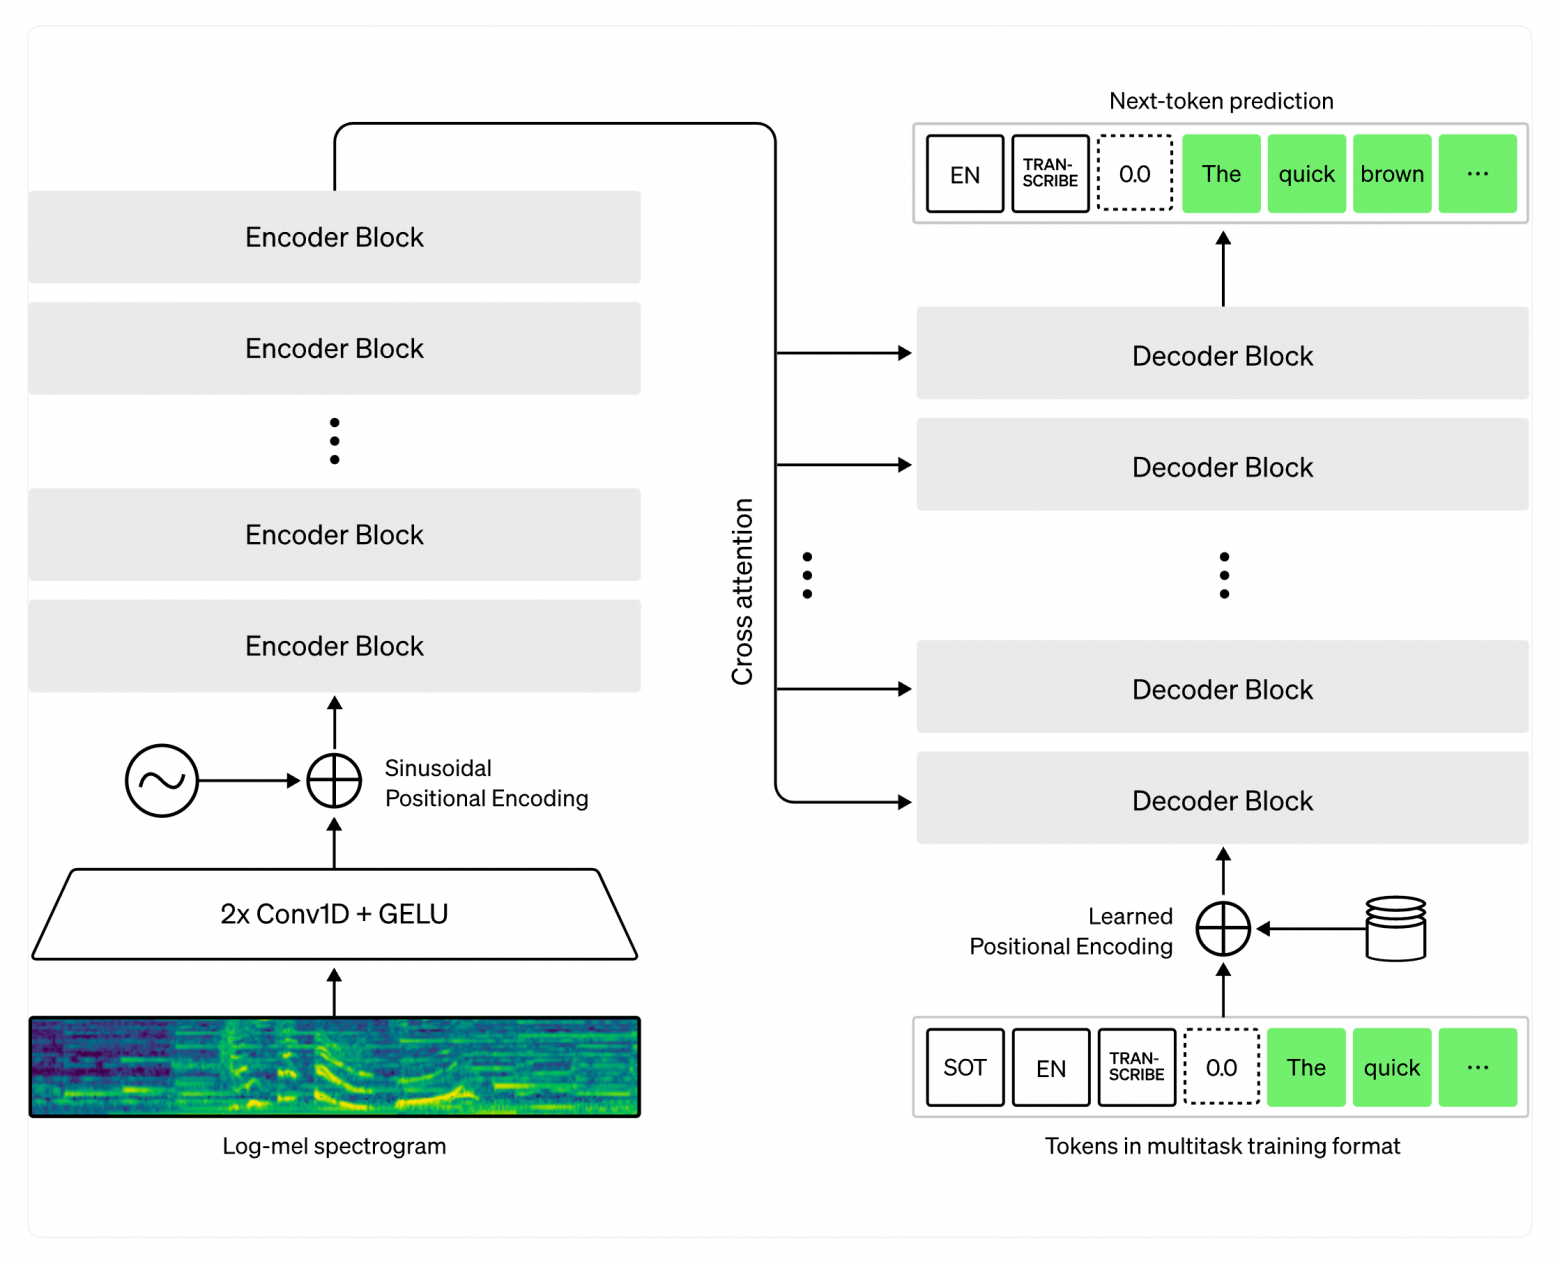

### The analogy with BERT:
| BERT | Whisper |
|------|------|
| Input data: text tokens | Input data:MEL-spectograms|
| Tokenizer → input_ids | Feature Extractor → input_features |
| Encoder only | Encoder + Decoder |
| Metrics: Accuracy, F1 | Metrics: **WER** (Word Error Rate) |
| Trainer | **Seq2SeqTrainer** |

### What is a MEL-spectrogram?

Audio is a wave (a change in air pressure over time). We can't directly feed
the wave into the transformer — we need to "describe" it. A MEL-spectrogram
is a **visual representation of sound**: the X-axis represents time, the Y-axis
represents frequencies (on a MEL scale that is close to human perception),
and the color represents intensity.

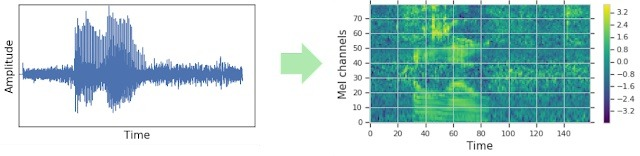

### What is WER?

**Word Error Rate** = (Substitutions + Deletions + Insertions) / the number of
words in the reference.
- WER = 0% → ideal recognition
- WER = 100% → complete failure
- Good Russian models: WER ~5-15% on Common Voice

## 📦 Importing modules

In [1]:
# Default modules
import os
import re

os.environ["DATASETS_DISABLE_TORCHCODEC"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"]        = "TRUE"

import numpy as np
import pandas as pd
import evaluate
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sys
import time

# Processing modules
from num2words import num2words
NUM2WORDS_AVAILABLE = True
import librosa
import librosa.display
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from collections import Counter
from tqdm.auto import tqdm

# NN modules
import torch
import torchaudio
import torchaudio.transforms as T
from datasets import (
    load_dataset, Features, Value,
    DatasetDict, concatenate_datasets, interleave_datasets,
    load_from_disk
)
from transformers import (
    WhisperForConditionalGeneration,
    WhisperProcessor,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    TrainerCallback,
    EarlyStoppingCallback,
)

print(f"🐍 Python: {sys.executable}")
print(f"🔥 PyTorch: {torch.__version__}")
print(f"🖥️ CUDA available: {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🎮 Augmentation device: {DEVICE}")

if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"⚡ CUDA version: {torch.version.cuda}")
    print(f"💾 Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("❌ CUDA not available")

🐍 Python: C:\Users\Vlad\anaconda3\envs\ml\python.exe
🔥 PyTorch: 2.4.0
🖥️ CUDA available: True
🎮 Augmentation device: cuda
🎮 GPU: NVIDIA GeForce RTX 4060
⚡ CUDA version: 11.8
💾 Memory: 8.59 GB


## 🔧 Configuration

In [2]:
# Model
MODEL_NAME = "openai/whisper-small"
OUTPUT_DIR = "./whisper-finetuned-ru-en"

# Dataset
SAVE_DIR = "./vastai_datasets"

# Params
MAX_TRAIN_SAMPLES = 2500
MAX_EVAL_SAMPLES  = 500
NUM_EPOCHS        = 3
BATCH_SIZE        = 4
LEARNING_RATE     = 1e-5
MAX_LABEL_LENGTH = 448

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 📥 Importing dataset

In [3]:
print("⬇️  Loading Russian dataset...")
dataset_ru = load_from_disk(os.path.join(SAVE_DIR, "common_voice_ru"))

print("⬇️  Loading English dataset...")
dataset_en = load_from_disk(os.path.join(SAVE_DIR, "common_voice_en"))

print("="*70)
for lang, ds in [("RU", dataset_ru), ("EN", dataset_en)]:
    print(f"   {lang}: train={len(ds['train']):,}, "
          f"val={len(ds['validation']):,}, "
          f"test={len(ds['test']):,}")

⬇️  Loading Russian dataset...
⬇️  Loading English dataset...
   RU: train=26,772, val=7,059, test=6,883
   EN: train=26,772, val=7,059, test=6,883


## 📊 Dataset analysis (EDA)

Before training, it is always important to analyze the data — which helps understand quality, identify problems and correct preprocessing decisions.

In [4]:
df_ru = dataset_ru["train"].to_pandas()
df_en = dataset_en["train"].to_pandas()

print("First 5 rows (Russian):")
df_ru[["path", "sentence", "gender", "age"]].head()

First 5 rows (Russian):


,path,sentence,gender,age
0,common_voice_ru_27400319.mp3,Сегодняшнее решение никоим образом не является...,female_feminine,thirties
1,common_voice_ru_18980309.mp3,"Последнего пленника втолкнули в будку, задвину...",male_masculine,twenties
2,common_voice_ru_31471458.mp3,"Ведь...— он не мог продолжать, рыдание останов...",male_masculine,twenties
3,common_voice_ru_26562394.mp3,Это мамонт какой-то.,None,None
4,common_voice_ru_38054794.mp3,"Спасайтесь, пожар!",female_feminine,teens


In [5]:
print("First 5 rows (English):")
df_en[["path", "sentence", "gender", "age"]].head()

First 5 rows (English):


,path,sentence,gender,age
0,common_voice_en_20540509.mp3,People making straight bets commonly employ th...,male_masculine,twenties
1,common_voice_en_22331972.mp3,Students come to Saint Xavier from throughout ...,female_feminine,twenties
2,common_voice_en_21738583.mp3,Also in the diaspora the Abu-Ghaben brothers f...,male_masculine,thirties
3,common_voice_en_20566207.mp3,Charron also connected Montaigne's scepticism ...,male_masculine,twenties
4,common_voice_en_20696810.mp3,East Prairie is the only other town on the hig...,male_masculine,twenties


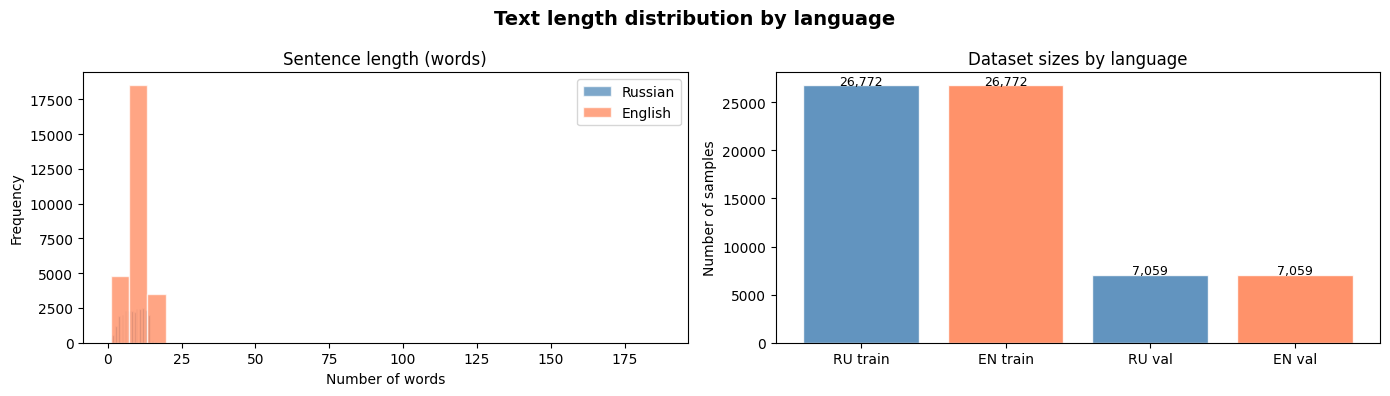

📝 Sentence length statistics (words):
        Russian   English
count  26772.00  26772.00
mean       8.64     10.30
std        3.48      2.96
min        1.00      1.00
25%        6.00      8.00
50%        9.00     11.00
75%       12.00     13.00
max       17.00    187.00


In [6]:
# Text length distribution by language
df_ru["text_len_words"] = df_ru["sentence"].str.split().str.len()
df_en["text_len_words"] = df_en["sentence"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Text length distribution by language", fontsize=14, fontweight="bold")

axes[0].hist(df_ru["text_len_words"], bins=30, color="steelblue",
             edgecolor="white", alpha=0.7, label="Russian")
axes[0].hist(df_en["text_len_words"], bins=30, color="coral",
             edgecolor="white", alpha=0.7, label="English")
axes[0].set_xlabel("Number of words")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Sentence length (words)")
axes[0].legend()

# Dataset size comparation
sizes = {
    "RU train": len(df_ru),
    "EN train": len(df_en),
    "RU val":   len(dataset_ru["validation"]),
    "EN val":   len(dataset_en["validation"]),
}
bars = axes[1].bar(
    sizes.keys(), sizes.values(),
    color=["steelblue", "coral", "steelblue", "coral"],
    edgecolor="white", alpha=0.85
)
axes[1].set_title("Dataset sizes by language")
axes[1].set_ylabel("Number of samples")
for bar, v in zip(bars, sizes.values()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 50, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("📝 Sentence length statistics (words):")
print(pd.DataFrame({
    "Russian": df_ru["text_len_words"].describe(),
    "English": df_en["text_len_words"].describe(),
}).round(2))

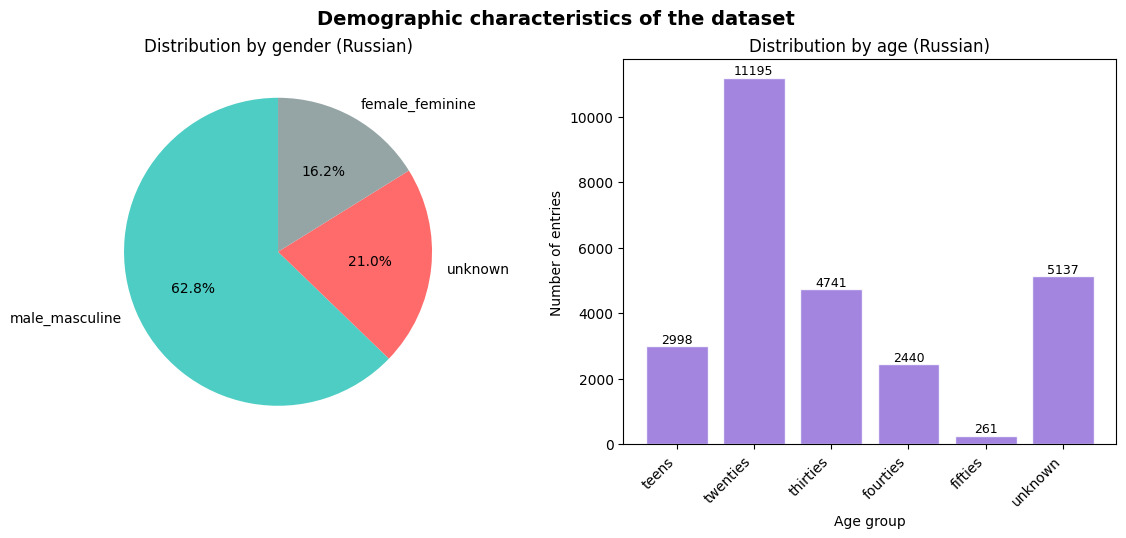

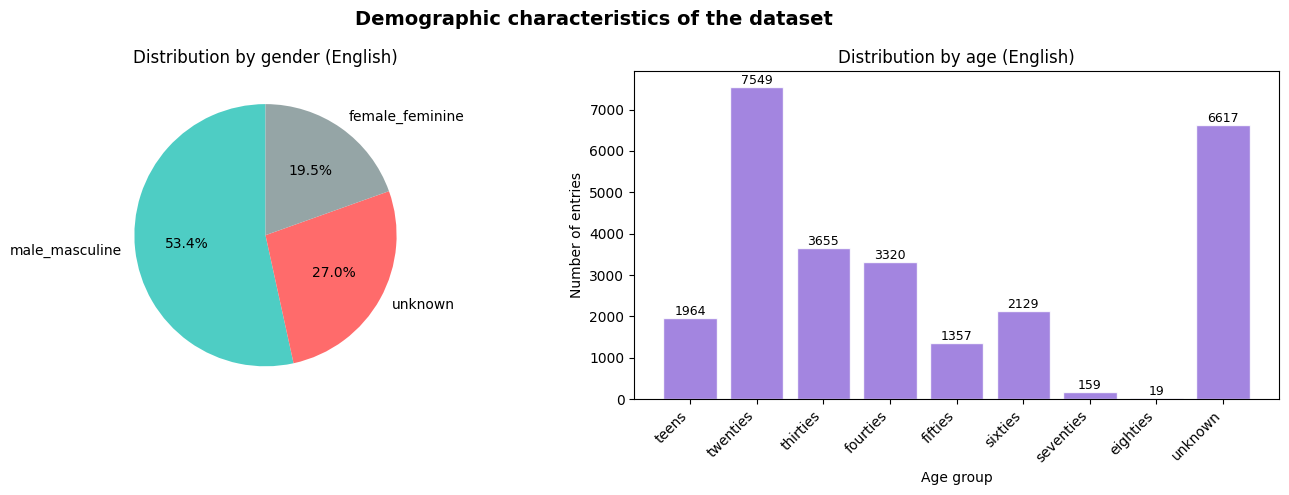

In [7]:
# Gender and age distribution
# Russian dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Demographic characteristics of the dataset", fontsize=14, fontweight="bold")

# Russian gender distribution
gender_counts = df_ru["gender"].fillna("unknown").value_counts()
axes[0].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=["#4ECDC4", "#FF6B6B", "#95A5A6"][:len(gender_counts)],
    startangle=90
)
axes[0].set_title("Distribution by gender (Russian)")

# Russian age distribution
age_order = ["teens","twenties","thirties","fourties","fifties","sixties","seventies","eighties"]
age_counts = df_ru["age"].fillna("unknown").value_counts()
age_counts = age_counts.reindex(
    [a for a in age_order if a in age_counts.index] +
    (["unknown"] if "unknown" in age_counts.index else [])
).dropna()

bars = axes[1].bar(range(len(age_counts)), age_counts.values,
                   color="mediumpurple", edgecolor="white", alpha=0.85)
axes[1].set_xticks(range(len(age_counts)))
axes[1].set_xticklabels(age_counts.index, rotation=45, ha="right")
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Number of entries")
axes[1].set_title("Distribution by age (Russian)")
for bar, val in zip(bars, age_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha="center", va="bottom", fontsize=9)

# English dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Demographic characteristics of the dataset", fontsize=14, fontweight="bold")

# English gender distribution
gender_counts = df_en["gender"].fillna("unknown").value_counts()
axes[0].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=["#4ECDC4", "#FF6B6B", "#95A5A6"][:len(gender_counts)],
    startangle=90
)
axes[0].set_title("Distribution by gender (English)")

# English age distribution
age_order = ["teens","twenties","thirties","fourties","fifties","sixties","seventies","eighties"]
age_counts = df_en["age"].fillna("unknown").value_counts()
age_counts = age_counts.reindex(
    [a for a in age_order if a in age_counts.index] +
    (["unknown"] if "unknown" in age_counts.index else [])
).dropna()

bars = axes[1].bar(range(len(age_counts)), age_counts.values,
                   color="mediumpurple", edgecolor="white", alpha=0.85)
axes[1].set_xticks(range(len(age_counts)))
axes[1].set_xticklabels(age_counts.index, rotation=45, ha="right")
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Number of entries")
axes[1].set_title("Distribution by age (English)")
for bar, val in zip(bars, age_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [8]:
# Votes distribution (audio quality)
# up_votes   — how many people marked the record as good
# down_votes — how many people marked the record as bad
# Low-quality recordings can make training more difficult!

for df, name in [(df_ru, "Russian"), (df_en, "English")]:
    df["up_votes"]   = pd.to_numeric(df["up_votes"],   errors="coerce").fillna(0)
    df["down_votes"] = pd.to_numeric(df["down_votes"], errors="coerce").fillna(0)
    bad = (df["down_votes"] > df["up_votes"]).sum()
    print(f"⚠️  {name}: records with more down_votes than up_votes: "
          f"{bad} ({bad/len(df)*100:.1f}%)")

⚠️  Russian: records with more down_votes than up_votes: 0 (0.0%)
⚠️  English: records with more down_votes than up_votes: 0 (0.0%)


⏱️  Measuring audio duration (sample of 200 recordings per language)...


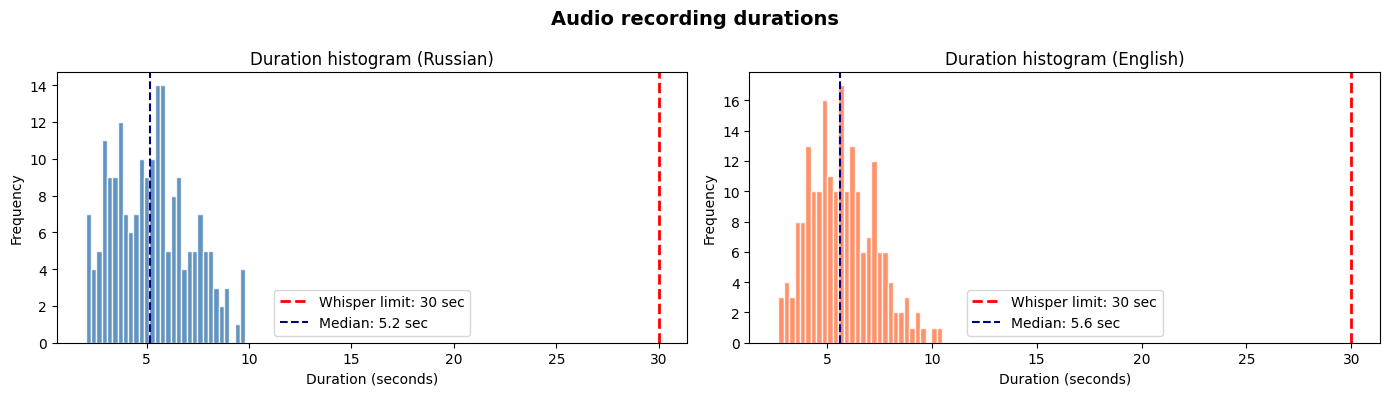


📊 Russian duration statistics:
   AVG:     5.27 sec
   Median:  5.19 sec
   Min/Max: 2.02 / 9.82 sec
   >30 sec: 0 ← Whisper will cut these off!

📊 English duration statistics:
   AVG:     5.69 sec
   Median:  5.62 sec
   Min/Max: 2.67 / 10.49 sec
   >30 sec: 0 ← Whisper will cut these off!


In [9]:
# Audio analysis: duration of recordings
# Whisper processes audio in fixed 30-second chunks.
# Recordings longer than 30 seconds will be cut off.
# Common Voice usually has short recordings (2–10 sec), so it's fine.

print("⏱️  Measuring audio duration (sample of 200 recordings per language)...")

def sample_durations(dataset, n=200):
    durations = []
    for i in range(min(n, len(dataset))):
        try:
            audio_filename = dataset[i]["audio_path"]
            audio_path = audio_filename  
            durations.append(librosa.get_duration(path=audio_path))
        except Exception as e:
            print(f"⚠️  Error loading {audio_filename}: {e}")
    return durations

dur_ru = sample_durations(dataset_ru["train"], n=200)
dur_en = sample_durations(dataset_en["train"], n=200)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Audio recording durations", fontsize=14, fontweight="bold")

for ax, durations, name, color in [
    (axes[0], dur_ru, "Russian", "steelblue"),
    (axes[1], dur_en, "English", "coral"),
]:
    ax.hist(durations, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(30, color="red", linestyle="--", linewidth=2, label="Whisper limit: 30 sec")
    ax.axvline(np.median(durations), color="navy", linestyle="--",
               label=f"Median: {np.median(durations):.1f} sec")
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Duration histogram ({name})")
    ax.legend()

plt.tight_layout()
plt.show()

for durations, name in [(dur_ru, "Russian"), (dur_en, "English")]:
    print(f"\n📊 {name} duration statistics:")
    print(f"   AVG:     {np.mean(durations):.2f} sec")
    print(f"   Median:  {np.median(durations):.2f} sec")
    print(f"   Min/Max: {min(durations):.2f} / {max(durations):.2f} sec")
    print(f"   >30 sec: {sum(1 for d in durations if d > 30)} ← Whisper will cut these off!")

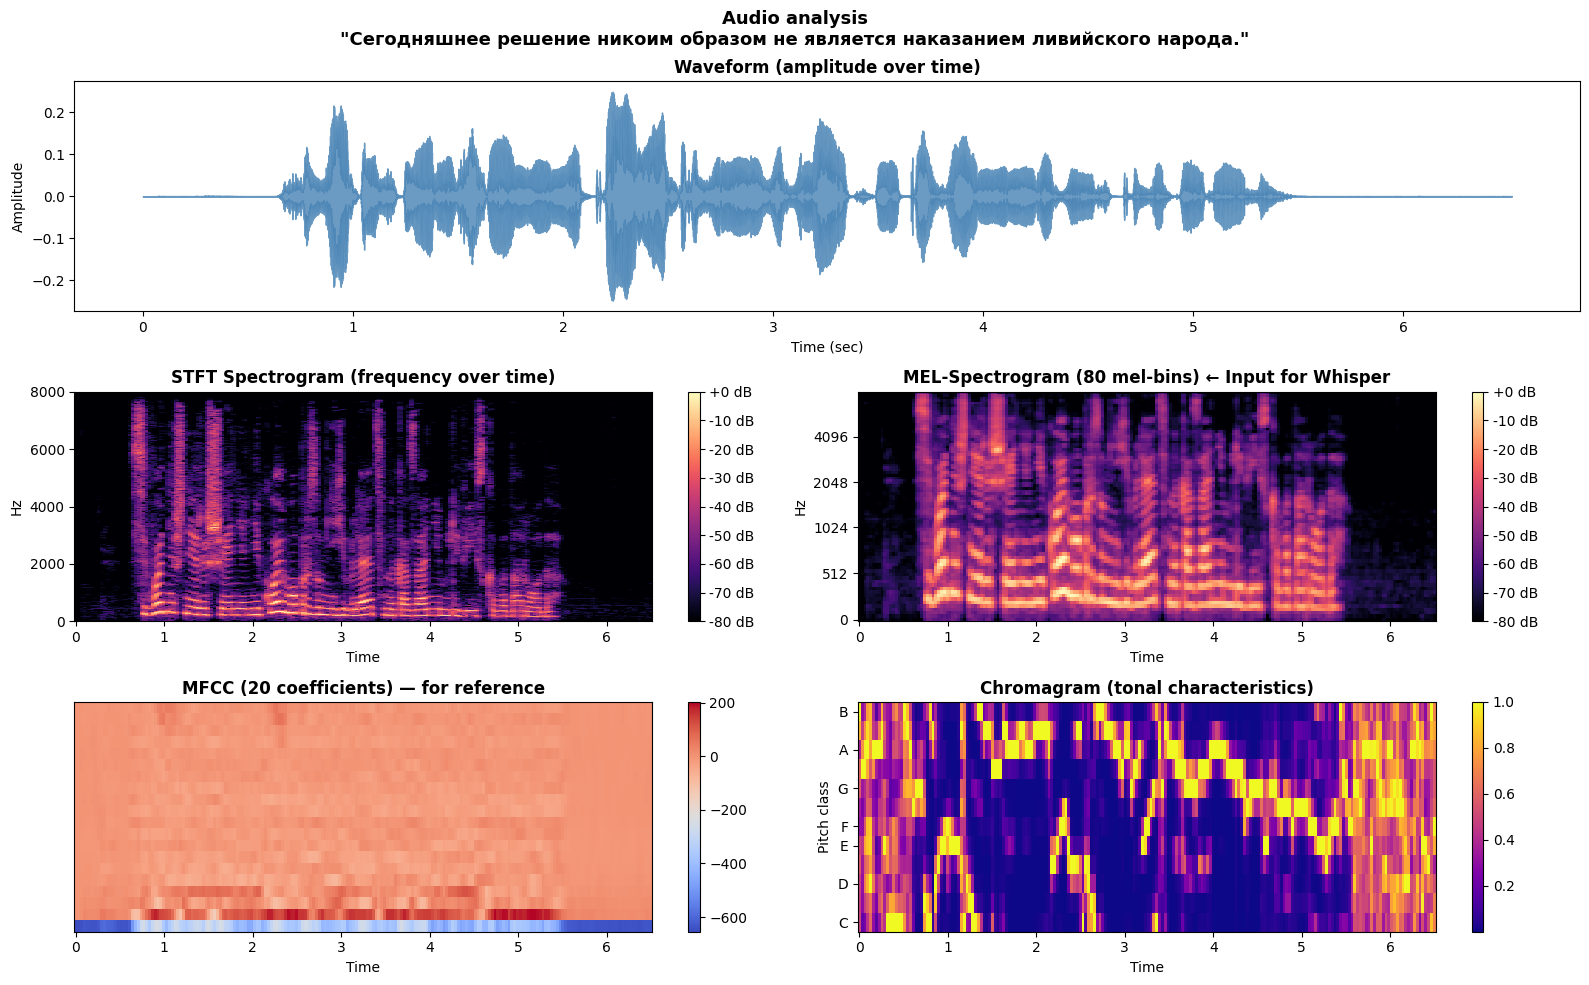


🔊 Audio parameters:
   Sample rate:         16000 Hz (Whisper requires 16 000 Hz)
   Duration:            6.52 sec
   Number of samples:   104,256
   MEL-spectrogram shape: (80, 204)  (mel-bins × time frames)


In [10]:
# Audio visualization: waveform, spectrogram, MEL-spectrogram
sample = dataset_ru["train"][0]
example_path = sample["audio_path"]
example_text = sample["sentence"]

audio, sr = librosa.load(example_path, sr=16000)

fig = plt.figure(figsize=(16, 10))
fig.suptitle(f'Audio analysis\n"{example_text}"', fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(3, 2, figure=fig)

# 1. Waveform (oscillogram)
ax1 = fig.add_subplot(gs[0, :])
librosa.display.waveshow(audio, sr=sr, ax=ax1, color="steelblue", alpha=0.8)
ax1.set_title("Waveform (amplitude over time)", fontweight="bold")
ax1.set_xlabel("Time (sec)")
ax1.set_ylabel("Amplitude")

# 2. STFT Spectrogram (Short Time Fourier Transform)
ax2 = fig.add_subplot(gs[1, 0])
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
img2 = librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz", ax=ax2)
fig.colorbar(img2, ax=ax2, format="%+2.0f dB")
ax2.set_title("STFT Spectrogram (frequency over time)", fontweight="bold")

# 3. MEL-Spectrogram — this is exactly what Whisper uses as input!
ax3 = fig.add_subplot(gs[1, 1])
mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=80)
mel_db   = librosa.power_to_db(mel_spec, ref=np.max)
img3 = librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel",
                                 ax=ax3, cmap="magma")
fig.colorbar(img3, ax=ax3, format="%+2.0f dB")
ax3.set_title("MEL-Spectrogram (80 mel-bins) ← Input for Whisper", fontweight="bold")

# 4. MFCC (Mel-Frequency Cepstral Coefficients)
ax4 = fig.add_subplot(gs[2, 0])
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
img4 = librosa.display.specshow(mfccs, sr=sr, x_axis="time", ax=ax4, cmap="coolwarm")
fig.colorbar(img4, ax=ax4)
ax4.set_title("MFCC (20 coefficients) — for reference", fontweight="bold")

# 5. Chromagram
ax5 = fig.add_subplot(gs[2, 1])
chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
img5 = librosa.display.specshow(chroma, sr=sr, x_axis="time", y_axis="chroma",
                                 ax=ax5, cmap="plasma")
fig.colorbar(img5, ax=ax5)
ax5.set_title("Chromagram (tonal characteristics)", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\n🔊 Audio parameters:")
print(f"   Sample rate:         {sr} Hz (Whisper requires 16 000 Hz)")
print(f"   Duration:            {len(audio)/sr:.2f} sec")
print(f"   Number of samples:   {len(audio):,}")
print(f"   MEL-spectrogram shape: {mel_spec.shape}  (mel-bins × time frames)")

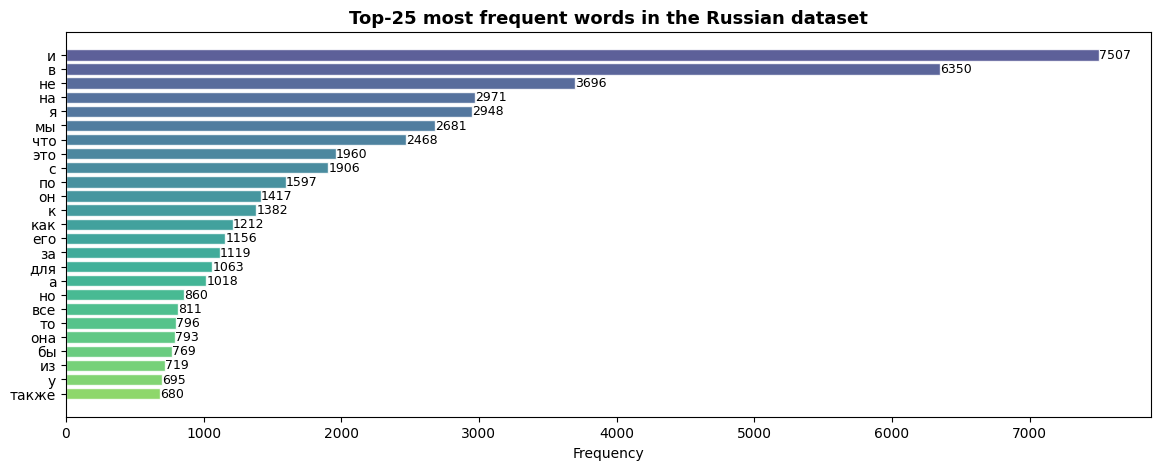

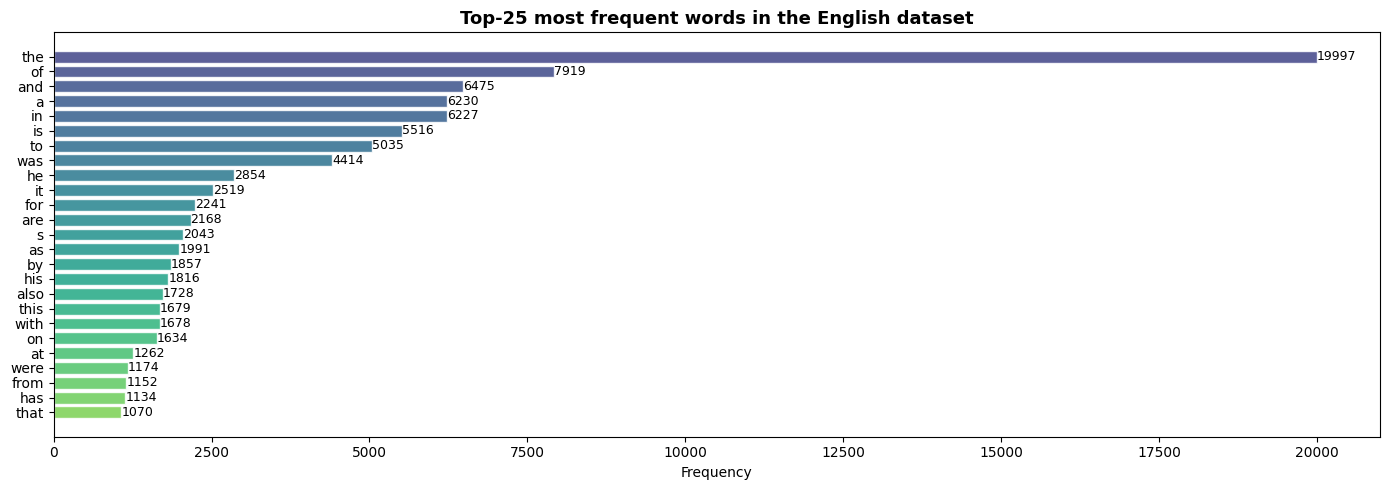


📚 Russian dataset vocabulary:
   Total words (with repetitions): 230,435
   Unique words:                   37,818

📚 English dataset vocabulary:
   Total words (with repetitions): 281,417
   Unique words:                   33,013


In [11]:
# Text analysis: most frequent words
all_words_ru = []
for text in df_ru["sentence"].dropna():
    all_words_ru.extend(re.findall(r'[а-яёА-ЯЁ]+', text.lower()))

all_words_en = []
for text in df_en["sentence"].dropna():
    all_words_en.extend(re.findall(r'[a-zA-Z]+', text.lower()))

word_freq_ru = Counter(all_words_ru)
top_words_ru = word_freq_ru.most_common(25)

word_freq_en = Counter(all_words_en)
top_words_en = word_freq_en.most_common(25)

# Russian top-25 words
fig, ax = plt.subplots(figsize=(14, 5))
words, counts = zip(*top_words_ru)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(words)))
bars = ax.barh(range(len(words)), counts, color=colors, edgecolor="white", alpha=0.85)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Top-25 most frequent words in the Russian dataset",
             fontsize=13, fontweight="bold")
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(count), va="center", fontsize=9)

# English top-25 words
fig, ax = plt.subplots(figsize=(14, 5))
words, counts = zip(*top_words_en)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(words)))
bars = ax.barh(range(len(words)), counts, color=colors, edgecolor="white", alpha=0.85)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Top-25 most frequent words in the English dataset",
             fontsize=13, fontweight="bold")
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(count), va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n📚 Russian dataset vocabulary:")
print(f"   Total words (with repetitions): {len(all_words_ru):,}")
print(f"   Unique words:                   {len(word_freq_ru):,}")
print("="*70)
print(f"\n📚 English dataset vocabulary:")
print(f"   Total words (with repetitions): {len(all_words_en):,}")
print(f"   Unique words:                   {len(word_freq_en):,}")

In [12]:
# Checking for problematic records
print("🔍 Dataset quality check:")
print()

for df, name in [(df_ru, "Russian"), (df_en, "English")]:
    print(f"  [{name}]")
    empty    = df["sentence"].isna().sum() + (df["sentence"] == "").sum()
    short    = (df["sentence"].str.len() < 3).sum()
    digits   = df["sentence"].str.contains(r'\d', na=False).sum()
    latin    = df["sentence"].str.contains(r'[a-zA-Z]', na=False).sum()
    dups     = df["sentence"].duplicated().sum()
    print(f"   Empty sentences:              {empty}")
    print(f"   Too short (<3 chars):         {short}")
    print(f"   Sentences with digits:        {digits} (⚠️ recommended to normalize)")
    print(f"   Sentences with Latin chars:   {latin}")
    print(f"   Duplicate sentences:          {dups}")
    print()

🔍 Dataset quality check:

  [Russian]
   Empty sentences:              0
   Too short (<3 chars):         0
   Sentences with digits:        0 (⚠️ recommended to normalize)
   Sentences with Latin chars:   6
   Duplicate sentences:          0

  [English]
   Empty sentences:              0
   Too short (<3 chars):         0
   Sentences with digits:        2 (⚠️ recommended to normalize)
   Sentences with Latin chars:   26772
   Duplicate sentences:          0



## 🧹 Preprocessing data

### Text normalization

For ASR important to normalize data before training:
- Remove extra space
- Reduce to lower case (optional — Whisper knows how to work with the register)
- Remove extra punktuation
- Write the numbers in words ("5" → "five") — otherwise the model won't be train correctly

**Important:** WER is computed on the normalized text, so normalization required by compute metrics.

In [13]:
def convert_numbers_to_words(text: str, lang: str = "ru") -> str:
    """
    Convert numbers in text to words for ASR training.
    """
    if not NUM2WORDS_AVAILABLE:
        return re.sub(r'\d+', '', text)
    
    def replace_number(match):
        try:
            num = int(match.group(0))
            return num2words(num, lang=lang)
        except:
            return match.group(0)
    
    return re.sub(r'\d+', replace_number, text)

def normalize_text(text: str, lang: str = "ru") -> str:
    """
    Basic text normalization for Russian and English ASR.
    Applied to sentences during training and to predictions during evaluation.
    """
    if not isinstance(text, str):
        return ""

    # Numbers to text
    text = convert_numbers_to_words(text, lang)

    # Lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Replace dash with space (for compound words)
    text = text.replace('-', ' ')

    # Remove everything except Cyrillic, Latin letters and spaces
    text = re.sub(r'[^\wа-яёa-z\s]', '', text)

    # Remove extra spaces again
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Test normalization
test_cases = [
    ("Привет, мир!", "ru"),
    ("В 2024 году...", "ru"),
    ("Hello, World!", "en"),
    ("It's a test — really!", "en"),
    ("Ново-Сибирск", "ru"),
    ("i have 5 apples", "en"),
    ("Мне 25 лет и 100 рублей", "ru"),
    ("Room 101 in 2024", "en"),
]

print("🧪 Test normalization:")
for text, lang in test_cases:
    normalized = normalize_text(text, lang=lang)
    print(f"  [{lang}] '{text}' → '{normalized}'")

🧪 Test normalization:
  [ru] 'Привет, мир!' → 'привет мир'
  [ru] 'В 2024 году...' → 'в две тысячи двадцать четыре году'
  [en] 'Hello, World!' → 'hello world'
  [en] 'It's a test — really!' → 'its a test really'
  [ru] 'Ново-Сибирск' → 'ново сибирск'
  [en] 'i have 5 apples' → 'i have five apples'
  [ru] 'Мне 25 лет и 100 рублей' → 'мне двадцать пять лет и сто рублей'
  [en] 'Room 101 in 2024' → 'room one hundred and one in two thousand and twenty four'


## 🤖 Importing model and processor

**WhisperProcessor** — it's a wrapper over two component:
1. `processor.feature_extractor` — transforming audio signal to the MEL-spectrogram
2. `processor.tokenizer` — transforming text to tokens (like usual tokenizer)

This is directly analogy with BERT, but BERT doesn't have the `feature_extractor`.

In [14]:
print(f"⬇️  Loading processor: {MODEL_NAME}")
processor = WhisperProcessor.from_pretrained(
    MODEL_NAME,
    language="ru",       # default language — will be overridden per example
    task="transcribe"
)

print(f"⬇️  Loading model: {MODEL_NAME}")
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

# Configure generation
model.generation_config.language          = None
model.generation_config.task             = "transcribe"
model.generation_config.forced_decoder_ids = None

# gradient_checkpointing saves VRAM at the cost of slightly slower training.
# Essential when training on a GPU with limited memory.
model.config.use_cache = False  # Must be disabled when using gradient_checkpointing
model.gradient_checkpointing_enable()

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Model parameters:")
print(f"   Total:      {total_params:,} ({total_params/1e6:.0f}M)")
print(f"   Trainable:  {trainable_params:,} ({trainable_params/1e6:.0f}M)")
print(f"   Vocab size: {model.config.vocab_size:,}")

⬇️  Loading processor: openai/whisper-small


⬇️  Loading model: openai/whisper-small


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]


📊 Model parameters:
   Total:      241,734,912 (242M)
   Trainable:  241,734,912 (242M)
   Vocab size: 51,865


In [15]:
# Feature extractor parameters
print("🔧 feature_extractor parameters:")
print(f"   Sampling rate:          {processor.feature_extractor.sampling_rate} Hz")
print(f"   n_mels (feature_size):  {processor.feature_extractor.feature_size}")
print(f"   n_fft:                  {processor.feature_extractor.n_fft}")
print(f"   hop_length:             {processor.feature_extractor.hop_length}")
print(f"   chunk_length:           {processor.feature_extractor.chunk_length} seconds (max)")
print()

# Test: show what input_features looks like
test_audio    = np.zeros(16000)  # 1 second of silence
test_features = processor.feature_extractor(test_audio, sampling_rate=16000)
print(f"📐 input_features shape (1 second): {test_features.input_features[0].shape}")
print(f"   → {test_features.input_features[0].shape[0]} mel-bins × "
      f"{test_features.input_features[0].shape[1]} time frames")
print(f"   → Whisper always pads to 30 seconds: 80 × 3000")

🔧 feature_extractor parameters:
   Sampling rate:          16000 Hz
   n_mels (feature_size):  80
   n_fft:                  400
   hop_length:             160
   chunk_length:           30 seconds (max)

📐 input_features shape (1 second): (80, 3000)
   → 80 mel-bins × 3000 time frames
   → Whisper always pads to 30 seconds: 80 × 3000


## 🔄 Preprocessing dataset

This is where we turn the raw data (path to the audio and text) in the, what model needs:
- `input_features` — mel-spectrogram (encoder input)
- `labels` — tokens of the target text (for decoder)

In [16]:
def prepare_dataset(batch, processor, is_train=False, augment=None):
    """
    Process one example:
    1. Load the audio and convert it to 16 kHz
    2. Calculate the MEL-spectrogram (input_features)
    3. Tokenize the normalized text (labels)

    The key bilingual difference: set_prefix_tokens(language=batch['language'])
    adds <|ru|> or <|en|> to the label tokens so the decoder learns
    to switch languages depending on the input audio.
    """
    import os
    import re
    import librosa
    import torch
    import torch.nn.functional as F
    import torchaudio.transforms as T
    from num2words import num2words

    def _num2words_local(text, lang):
        def replace(m):
            try:
                return num2words(int(m.group(0)), lang=lang)
            except Exception:
                return m.group(0)
        return re.sub(r'\d+', replace, text)
    
    def _normalize(text, lang):
        # Repeated inside the function because multiprocessing
        # workers don't share the outer scope
        if not isinstance(text, str):
            return ""
        text = _num2words_local(text, lang)
        text = text.lower()
        text = text.replace('-', ' ')
        text = re.sub(r'[^\wа-яёa-z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    try:
        MAX_LABEL_LENGTH = 448
        
        lang = batch["language"]

        audio_path = batch["audio_path"]
        
        # Skip corrupted files
        if not audio_path or not os.path.exists(audio_path):
            batch["input_features"] = None
            batch["labels"] = None
            batch["valid"] = False
            return batch
        
        # Step 1: load audio
        # sr=16 000 — Whisper requires exactly 16 kHz.
        audio_array, sample_rate = librosa.load(audio_path, sr=16000)

        # Step 2: calculate MEL-spectrogram
        # Result shape: (80, 3000) — 80 mel-bins × 3000 time frames (= 30 sec)
        batch["input_features"] = processor.feature_extractor(
            audio_array, sampling_rate=sample_rate
        ).input_features[0]

        # Step 3: tokenize the text
        # This prepends <|ru|> or <|en|> to the token sequence.
        processor.tokenizer.set_prefix_tokens(language=lang, task="transcribe")
        batch["labels"] = processor.tokenizer(
            _normalize(batch["sentence"], lang)
        ).input_ids

        # Step 4: remove labels longer than 448 token
        if len(batch["labels"]) > MAX_LABEL_LENGTH:
            batch["valid"] = False
            batch["input_features"] = None
            batch["labels"] = None
            return batch

        batch["valid"] = True

    except Exception as e:
        print(f"❌ Error [{batch.get('audio_path', '?')}]: {e}")
        batch["input_features"] = None
        batch["labels"]         = None
        batch["valid"]          = False

    return batch


KEEP_COLS = ["input_features", "labels", "valid"]


def process_split(ds, max_samples, desc, is_train=False):
    """Limit size, process and filter one dataset split."""
    if max_samples is None:
        take = len(ds)
    else:
        BUFFER_MULTIPLIER = 3
        take = min(max_samples * BUFFER_MULTIPLIER, len(ds))

    ds = ds.select(range(take))
    ds = ds.map(
        prepare_dataset,
        fn_kwargs={
            "processor": processor,
            "is_train": is_train
        },
        num_proc=4,
        desc=desc,
        remove_columns=[c for c in ds.column_names if c not in KEEP_COLS],
    )

    total_before = len(ds)
    
    ds = ds.filter(
        lambda x: x,
        input_columns=["valid"],
        num_proc=4,
    )

    total_after = len(ds)
    filtered_out = total_before - total_after
    print(f"   ⚠️  {desc}: отфильтровано {filtered_out:,} из {total_before:,} "
          f"({filtered_out/total_before*100:.1f}%)")

    ds = ds.remove_columns(["valid"])

    # Trim to exactly max_samples if we got more than needed
    if max_samples is not None and len(ds) > max_samples:
        ds = ds.select(range(max_samples))

    return ds


print("⚙️  Processing Russian dataset...")
ru_train = process_split(dataset_ru["train"],      MAX_TRAIN_SAMPLES, "RU train", is_train=True)
ru_val   = process_split(dataset_ru["validation"], MAX_EVAL_SAMPLES,  "RU val",   is_train=False)

print("⚙️  Processing English dataset...")
en_train = process_split(dataset_en["train"],      MAX_TRAIN_SAMPLES, "EN train", is_train=True)
en_val   = process_split(dataset_en["validation"], MAX_EVAL_SAMPLES,  "EN val",   is_train=False)

print("✅ Processing complete")

⚙️  Processing Russian dataset...
   ⚠️  RU train: отфильтровано 0 из 7,500 (0.0%)
   ⚠️  RU val: отфильтровано 0 из 1,500 (0.0%)
⚙️  Processing English dataset...
   ⚠️  EN train: отфильтровано 1 из 7,500 (0.0%)
   ⚠️  EN val: отфильтровано 0 из 1,500 (0.0%)
✅ Processing complete


In [17]:
# Merge RU and EN datasets
#
# interleave_datasets alternates between RU and EN examples in each batch.
# This prevents the model from overfitting to one language at a time.
# probabilities=[0.5, 0.5] means an equal mix.

combined_train = interleave_datasets(
    [ru_train, en_train],
    probabilities=[0.5, 0.5],
    seed=SEED,
)

# For validation — simple concatenation is fine.
# We just want to measure the overall WER across both languages.
combined_val = concatenate_datasets([ru_val, en_val]).shuffle(seed=SEED)

dataset = DatasetDict({
    "train":      combined_train,
    "validation": combined_val,
})

print(f"✅ Combined dataset ready:")
print(f"   Train:      {len(dataset['train']):,} samples "
      f"({len(ru_train):,} RU + {len(en_train):,} EN)")
print(f"   Validation: {len(dataset['validation']):,} samples "
      f"({len(ru_val):,} RU + {len(en_val):,} EN)")

✅ Combined dataset ready:
   Train:      4,921 samples (2,500 RU + 2,500 EN)
   Validation: 1,000 samples (500 RU + 500 EN)


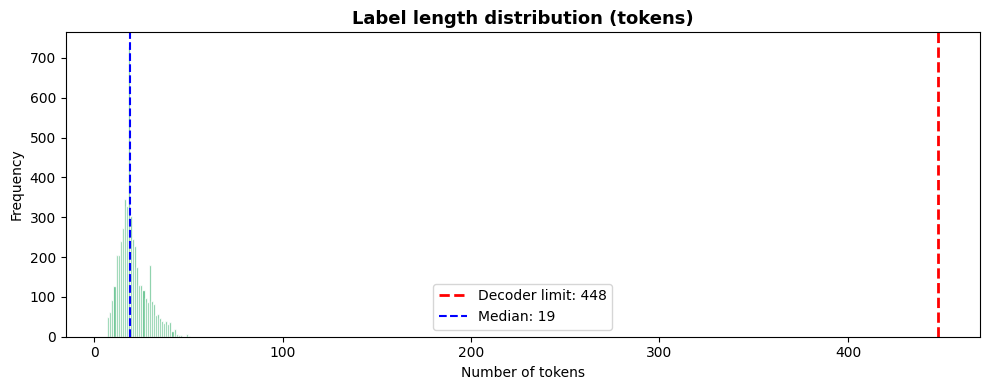

⚠️  Labels longer than 448 tokens: 0


In [18]:
# Token length analysis after processing
# Whisper's decoder has a max_length of 448 tokens — longer labels will be truncated!

label_lengths = [len(ids) for ids in dataset["train"]["labels"]]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(label_lengths, bins=40, color="mediumseagreen", edgecolor="white", alpha=0.85)
ax.axvline(448, color="red", linestyle="--", linewidth=2, label="Decoder limit: 448")
ax.axvline(np.median(label_lengths), color="blue", linestyle="--",
           label=f"Median: {np.median(label_lengths):.0f}")
ax.set_xlabel("Number of tokens")
ax.set_ylabel("Frequency")
ax.set_title("Label length distribution (tokens)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

too_long = sum(1 for l in label_lengths if l > 448)
print(f"⚠️  Labels longer than 448 tokens: {too_long}")

## 📦 Data Collator

Data Collator «collects» batch from individual examples:  
- Padding `input_features` to the same length
- Padding `labels` to the same length, filling `-100` (ignored by loss)  
- Remove `bos_token` from marks (Whisper is not trained to predict it)

In [19]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    is_train:  bool = False
    device:    str  = "cuda"

    def _augment_batch(self, input_features: torch.Tensor) -> torch.Tensor:
        """
        Apply augmentation to audio waveform (torch tensor).
        waveform shape: (channels, samples) или (samples,)
        """
        B = input_features.shape[0]
        
        # 1. Add Gaussian noise (30% chance)
        mask  = torch.rand(B, device=self.device) < 0.3
        noise = torch.randn_like(input_features) * 0.005
        input_features[mask] = input_features[mask] + noise[mask]
        
        # 2. Random gain/volume (30% chance)
        mask = torch.rand(B, device=self.device) < 0.3
        gain = (torch.rand(B, device=self.device) * 0.2 + 0.9).view(B, 1, 1)
        input_features[mask] = input_features[mask] * gain[mask]
        
        # 3. Pitch shift using resample (30% chance)
        mask = torch.rand(B, device=self.device) < 0.3
        for i in mask.nonzero(as_tuple=True)[0]:
            f_start = torch.randint(0, 60, (1,)).item()
            f_width = torch.randint(1, 20, (1,)).item()
            input_features[i, f_start:f_start+f_width, :] = 0.0
        
        # 4. Time shift ±100ms (20% chance)
        mask = torch.rand(B, device=self.device) < 0.3
        for i in mask.nonzero(as_tuple=True)[0]:
            t_start = torch.randint(0, 2800, (1,)).item()
            t_width = torch.randint(1, 200, (1,)).item()
            input_features[i, :, t_start:t_start+t_width] = 0.0
        
        return input_features

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # Pad input_features (audio) up to 30 seconds
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        # Augmentation
        if self.is_train:
            batch["input_features"] = self._augment_batch(
                batch["input_features"].to(self.device)
            ).cpu()

        # Pad labels (text)
        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch   = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # Replace pad_token in labels with -100.
        # -100 is a special value: CrossEntropyLoss ignores these positions.
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch["attention_mask"].ne(1), -100
        )

        # Remove the BOS token from the start of labels.
        # Whisper is not trained to predict it.
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch


train_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor, is_train=True,  device="cuda"
)
eval_collator  = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor, is_train=False, device="cuda"
)
print("✅ Data Collator created")

✅ Data Collator created


## 📏 Evaluation metrics (WER)

**WER = (S + D + I) / N**, where:
- S (Substitutions) — wrong words 
- D (Deletions) — missing words
- I (Insertions) — unnecessary words
- N — number of words in the reference

Example: reference `"я иду домой"`, predict `"я иду в дом"`  
→ S=1 (дом instead of домой), I=1 (unnecessary "в") → WER = 2/3 = 66.7%

In [20]:
wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids  = pred.predictions
    label_ids = pred.label_ids

    # Replace -100 back to pad_token for decoding
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    # Decode tokens to text
    pred_str  = processor.tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    # Normalize both before calculating WER!
    pred_str  = [normalize_text(s) for s in pred_str]
    label_str = [normalize_text(s) for s in label_str]

    # Filter empty sentences
    pairs = [(p, r) for p, r in zip(pred_str, label_str) if r.strip()]
    if not pairs:
        return {"wer": 1.0}
    pred_str, label_str = zip(*pairs)

    wer = 100 * wer_metric.compute(predictions=list(pred_str), references=list(label_str))
    return {"wer": round(wer, 3)}


# WER demonstration
print("🧪 WER demonstration:")
examples = [
    ("я иду домой",  "я иду домой"),       # Perfect
    ("я иду в дом",  "я иду домой"),       # Bad
    ("привет мир",   "привет весь мир"),   # Missing word
    ("hello world",  "hello world"),       # Perfect (English)
]
for pred, ref in examples:
    w = 100 * wer_metric.compute(predictions=[pred], references=[ref])
    print(f"   Reference: '{ref}' | Prediction: '{pred}' → WER: {w:.1f}%")

🧪 WER demonstration:
   Reference: 'я иду домой' | Prediction: 'я иду домой' → WER: 0.0%
   Reference: 'я иду домой' | Prediction: 'я иду в дом' → WER: 66.7%
   Reference: 'привет весь мир' | Prediction: 'привет мир' → WER: 33.3%
   Reference: 'hello world' | Prediction: 'hello world' → WER: 0.0%


## 🚀 Model training

### Key differences from training the BERT model:
1. Use `Seq2SeqTrainer` (not `Trainer`) — it calls `model.generate()` by evaluation
2. `predict_with_generate=True` — necessary for correctly computing WER metric
3. `generation_max_length` — maximum length of generating text
4. `fp16=True` — mixed precision speeds up training on GPU and saves VRAM

In [21]:
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,

    # Batch size and gradient accumulation
    per_device_train_batch_size=6,
    per_device_eval_batch_size=6,
    gradient_accumulation_steps=3,

    # Training parameters
    learning_rate=LEARNING_RATE,
    warmup_steps=1000,
    num_train_epochs=NUM_EPOCHS,
    lr_scheduler_type="cosine",

    # Regularization:
    weight_decay=0.01,
    max_grad_norm=0.0,  

    # Memory and speed
    bf16=True,
    fp16=False,
    gradient_checkpointing=True,

    # Evaluation and checkpointing
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    save_total_limit=2,

    # Seq2Seq-specific parameters
    # This is the main difference from the regular Trainer!
    predict_with_generate=True,   # Uses model.generate() during evaluation
    generation_max_length=225,    # Maximum tokens generated per example

    # Other
    remove_unused_columns=False,
    label_names=["labels"],
    push_to_hub=False,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    report_to="none",
    seed=SEED,
)

print("✅ TrainingArguments configured")
print(f"   Effective batch size: {BATCH_SIZE * training_args.gradient_accumulation_steps}")
print(f"   Steps per epoch:      {len(dataset['train']) // (BATCH_SIZE * training_args.gradient_accumulation_steps)}")

✅ TrainingArguments configured
   Effective batch size: 12
   Steps per epoch:      410


In [22]:
class TrainingProgressCallback(TrainerCallback):
    """Shows detailed training progress after each step and epoch."""

    def __init__(self):
        self.epoch_start_time = None
        self.train_start_time = None
        self.current_epoch    = 0

    def on_train_begin(self, args, state, control, **kwargs):
        self.train_start_time = time.time()
        total_steps = state.max_steps
        print(f"\n{'='*70}")
        print(f"🚀 Training started")
        print(f"   Total steps:    {total_steps}")
        print(f"   Epochs:         {args.num_train_epochs}")
        print(f"   Steps/epoch:    {total_steps // int(args.num_train_epochs)}")
        print(f"   Batch size:     {args.per_device_train_batch_size} × "
              f"{args.gradient_accumulation_steps} accum = "
              f"{args.per_device_train_batch_size * args.gradient_accumulation_steps} effective")
        print(f"   Device:         {args.device}")
        print(f"{'='*70}\n")

    def on_epoch_begin(self, args, state, control, **kwargs):
        self.epoch_start_time = time.time()
        self.current_epoch    = int(state.epoch) + 1
        total_epochs          = int(args.num_train_epochs)
        print(f"\n{'─'*70}")
        print(f"📅 Epoch {self.current_epoch} / {total_epochs}  started")
        print(f"{'─'*70}")

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return

        # Show only training steps (not eval)
        if "loss" in logs and "eval_loss" not in logs:
            step        = state.global_step
            total_steps = state.max_steps
            loss        = logs.get("loss", 0)
            lr          = logs.get("learning_rate", 0)
            progress    = step / total_steps

            # Time estimate
            elapsed     = time.time() - self.train_start_time
            eta_seconds = (elapsed / step * (total_steps - step)) if step > 0 else 0
            eta_min     = int(eta_seconds // 60)
            eta_sec     = int(eta_seconds % 60)

            # Progress bar (30 chars)
            filled    = int(30 * progress)
            bar       = "█" * filled + "░" * (30 - filled)

            print(f"  Step {step:>4}/{total_steps}  [{bar}] {progress*100:5.1f}%"
                  f"  loss={loss:.4f}  lr={lr:.2e}  ETA={eta_min}m{eta_sec:02d}s")

    def on_epoch_end(self, args, state, control, **kwargs):
        epoch_time = time.time() - self.epoch_start_time
        print(f"\n⏱️  Epoch {self.current_epoch} finished in "
              f"{int(epoch_time//60)}m{int(epoch_time%60):02d}s")

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return
        eval_loss = metrics.get("eval_loss", "—")
        eval_wer  = metrics.get("eval_wer",  "—")
        print(f"\n📊 Eval results  (epoch {self.current_epoch}):")
        print(f"   eval_loss = {eval_loss:.4f}" if isinstance(eval_loss, float) else f"   eval_loss = {eval_loss}")
        print(f"   eval_wer  = {eval_wer:.2f}%" if isinstance(eval_wer,  float) else f"   eval_wer  = {eval_wer}")

    def on_train_end(self, args, state, control, **kwargs):
        total_time = time.time() - self.train_start_time
        best_metric = state.best_metric
        print(f"\n{'='*70}")
        print(f"✅ Training complete!")
        print(f"   Total time: {int(total_time//60)}m{int(total_time%60):02d}s")
        print(f"   Best WER:   {best_metric:.2f}%" if best_metric else "")
        print(f"   Best checkpoint: {state.best_model_checkpoint}")
        print(f"{'='*70}\n")

In [23]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    data_collator=train_collator,
    compute_metrics=compute_metrics,
    callbacks=[TrainingProgressCallback(), EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.eval_data_collator = eval_collator
trainer.train()


🚀 Training started
   Total steps:    822
   Epochs:         3
   Steps/epoch:    274
   Batch size:     6 × 3 accum = 18 effective
   Device:         cuda:0


──────────────────────────────────────────────────────────────────────
📅 Epoch 1 / 3  started
──────────────────────────────────────────────────────────────────────


C:\Users\Vlad\anaconda3\envs\ml\lib\site-packages\transformers\integrations\sdpa_attention.py:92: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
C:\Users\Vlad\anaconda3\envs\ml\lib\site-packages\torch\utils\checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Epoch,Training Loss,Validation Loss,Wer
1,No log,0.731233,85.125000
2,3.331666,0.382349,41.402000
3,3.331666,0.309187,32.126000



⏱️  Epoch 1 finished in 13m38s


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

...


⏱️  Epoch 3 finished in 13m08s

📊 Eval results  (epoch 3):
   eval_loss = 0.3092
   eval_wer  = 32.13%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].



✅ Training complete!
   Total time: 57m49s
   Best WER:   32.13%
   Best checkpoint: ./whisper-finetuned-ru-en\checkpoint-822



TrainOutput(global_step=822, training_loss=2.287677365787998, metrics={'train_runtime': 3469.4064, 'train_samples_per_second': 4.255, 'train_steps_per_second': 0.237, 'total_flos': 4.26038626492416e+18, 'train_loss': 2.287677365787998, 'epoch': 3.0})

In [24]:
# Save the final model
trainer.save_model(f"{OUTPUT_DIR}-final")
processor.save_pretrained(f"{OUTPUT_DIR}-final")
print(f"✅ Model saved to: {OUTPUT_DIR}-final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to: ./whisper-finetuned-ru-en-final


## 📈 Training results analysis

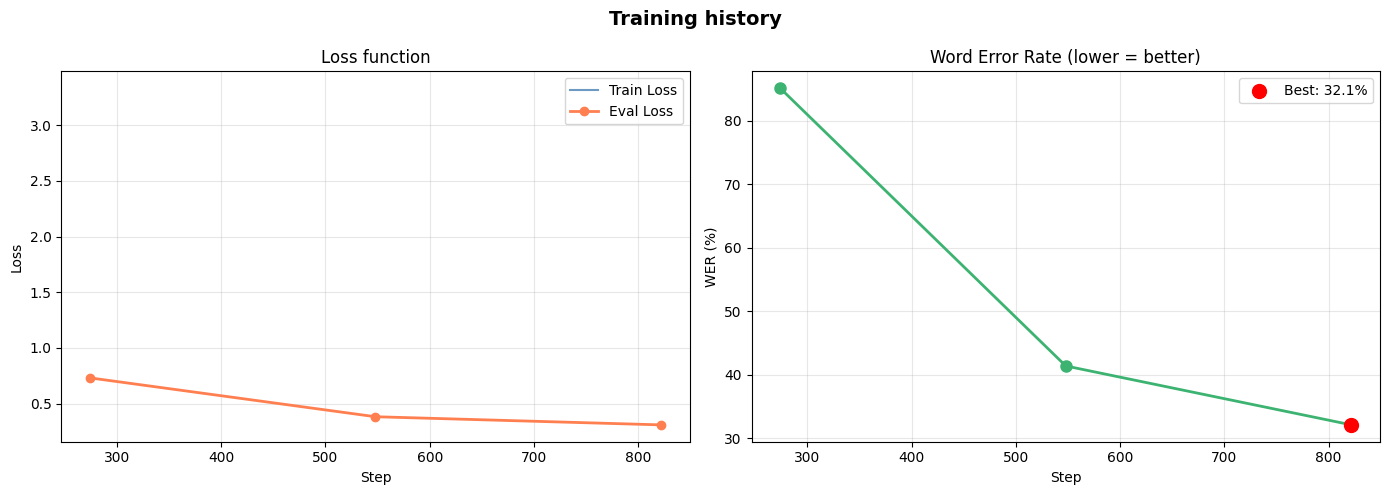

In [25]:
log_history = trainer.state.log_history

train_logs = [l for l in log_history if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in log_history if "eval_loss" in l]

if train_logs and eval_logs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training history", fontsize=14, fontweight="bold")

    train_steps = [l["step"] for l in train_logs]
    train_loss  = [l["loss"] for l in train_logs]
    eval_steps  = [l["step"] for l in eval_logs]
    eval_loss   = [l["eval_loss"] for l in eval_logs]

    axes[0].plot(train_steps, train_loss, label="Train Loss", color="steelblue", alpha=0.8)
    axes[0].plot(eval_steps, eval_loss, label="Eval Loss", color="coral", marker="o", linewidth=2)
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss function")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    eval_wer = [l.get("eval_wer") for l in eval_logs if "eval_wer" in l]
    if eval_wer:
        wer_steps = [l["step"] for l in eval_logs if "eval_wer" in l]
        axes[1].plot(wer_steps, eval_wer, color="mediumseagreen",
                     marker="o", linewidth=2, markersize=8)
        axes[1].set_xlabel("Step")
        axes[1].set_ylabel("WER (%)")
        axes[1].set_title("Word Error Rate (lower = better)")
        axes[1].grid(alpha=0.3)
        best_idx = eval_wer.index(min(eval_wer))
        axes[1].scatter([wer_steps[best_idx]], [eval_wer[best_idx]],
                        color="red", s=100, zorder=5,
                        label=f"Best: {eval_wer[best_idx]:.1f}%")
        axes[1].legend()

    plt.tight_layout()
    plt.show()

## 🧪 Model testing

In [23]:
model_path = "whisper-finetuned-ru-en-final"

model = WhisperForConditionalGeneration.from_pretrained(model_path)
processor = WhisperProcessor.from_pretrained(model_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 768)
      (layers): ModuleList(
        (0-11): 12 x WhisperEncoderLayer(
          (self_attn): WhisperAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (f

In [24]:
AUDIO_DIR_RU = os.path.join(SAVE_DIR, "audio_ru")
AUDIO_DIR_EN = os.path.join(SAVE_DIR, "audio_en")

def transcribe(audio_path: str, model, processor, language: str, device: str) -> str:
    audio_array, _ = librosa.load(audio_path, sr=16000)

    input_features = processor.feature_extractor(
        audio_array,
        sampling_rate=16000,
        return_tensors="pt"
    ).input_features.to(device)

    forced_decoder_ids = processor.get_decoder_prompt_ids(
        language=language,
        task="transcribe"
    )

    with torch.no_grad():
        predicted_ids = model.generate(
            input_features,
            forced_decoder_ids=forced_decoder_ids,
            max_new_tokens=225,
        )

    transcription = processor.tokenizer.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0].strip()

    return transcription

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

df_ru_val = dataset_ru["validation"].to_pandas()
df_en_val = dataset_en["validation"].to_pandas()

results = []

for lang_df, audio_dir, lang_code, lang_name in [
    (df_ru_val, AUDIO_DIR_RU, "ru", "Russian"),
    (df_en_val, AUDIO_DIR_EN, "en", "English"),
]:
    print(f"\n🎯 {lang_name} examples:")
    print("=" * 60)
    
    successful_count = 0
    max_attempts = 50
    
    while successful_count < 10 and max_attempts > 0:
        row = lang_df.sample(1).iloc[0]
        
        audio_path = os.path.join(audio_dir, row["path"])
        reference = normalize_text(row["sentence"])
        
        try:
            prediction = transcribe(audio_path, model, processor, lang_code, device)
            prediction_norm = normalize_text(prediction)
            wer_score = 100 * wer_metric.compute(
                predictions=[prediction_norm], references=[reference]
            ) if reference.strip() else None

            results.append({
                "lang": lang_name, 
                "reference": reference,
                "prediction": prediction_norm, 
                "wer": wer_score
            })

            status = "✅" if wer_score is not None and wer_score < 20 else "⚠️"
            print(f"{status} Reference:  {reference}")
            print(f"   Prediction: {prediction_norm}")
            if wer_score is not None:
                print(f"   WER: {wer_score:.1f}%")
            print()
            
            successful_count += 1
            
        except Exception as e:
            max_attempts -= 1
    
    if successful_count < 10:
        print(f"⚠️ Warning: Only {successful_count}/10 successful transcriptions for {lang_name}")


🎯 Russian examples:


C:\Users\Vlad\anaconda3\envs\ml\lib\site-packages\transformers\integrations\sdpa_attention.py:92: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.gener

✅ Reference:  эти фонды работают в партнерстве с местными коммерческими банками
   Prediction: эти фунты работают в партнерстве с местными коммерческими банками
   WER: 11.1%



Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Reference:  почему нету кафедры научного коммунизма
   Prediction: почему нету кафедры научного коммунизма
   WER: 0.0%



...

⚠️ Reference:  ill bet its a summons
   Prediction: ar bet gribu esamams
   WER: 80.0%



Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


⚠️ Reference:  simon loves musical theatre
   Prediction: sayman laus musical theatre
   WER: 50.0%



Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


⚠️ Reference:  the close of carews life is absolutely obscure
   Prediction: the close of karius live is absolutely obscure
   WER: 25.0%

⚠️ Reference:  through olcott he learned of hollywoods canadian community
   Prediction: through all court he learned of hollywoods canadian community
   WER: 25.0%



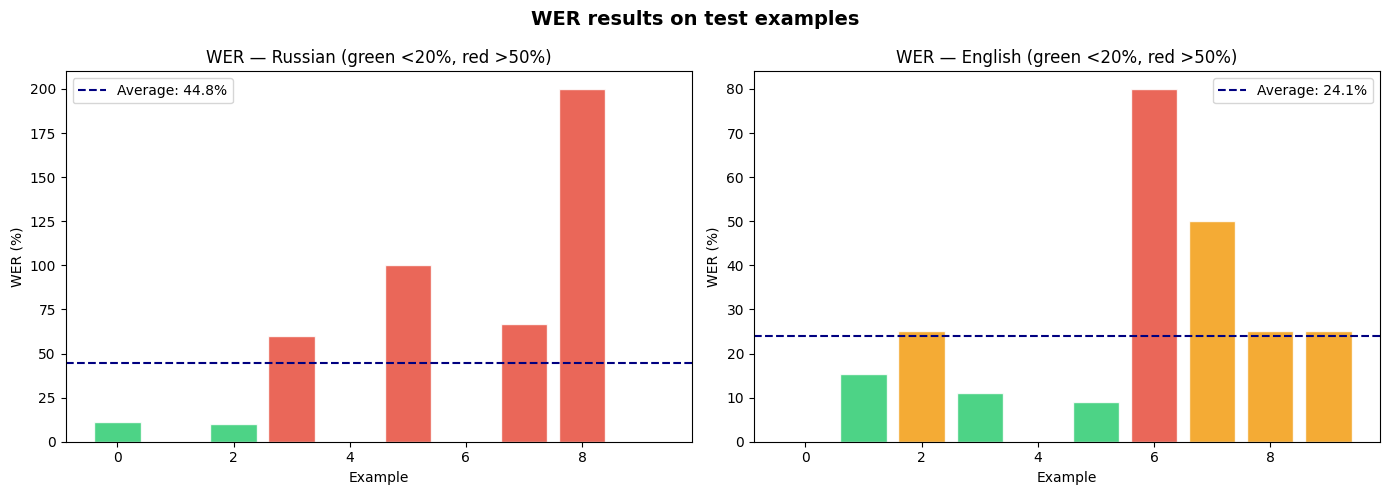


📊 Final results:
   Russian — Average WER: 44.8%, Median: 10.6%
   English — Average WER: 24.1%, Median: 20.2%


In [26]:
# Visualize test results by language
if results:
    ru_wer = [r["wer"] for r in results if r["lang"] == "Russian" and r["wer"] is not None]
    en_wer = [r["wer"] for r in results if r["lang"] == "English" and r["wer"] is not None]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("WER results on test examples", fontsize=14, fontweight="bold")

    for ax, wer_values, name, color in [
        (axes[0], ru_wer, "Russian", "steelblue"),
        (axes[1], en_wer, "English", "coral"),
    ]:
        if not wer_values:
            continue
        bar_colors = ["#2ECC71" if w < 20 else "#E74C3C" if w > 50 else "#F39C12"
                      for w in wer_values]
        ax.bar(range(len(wer_values)), wer_values, color=bar_colors,
               edgecolor="white", alpha=0.85)
        ax.axhline(np.mean(wer_values), color="navy", linestyle="--",
                   label=f"Average: {np.mean(wer_values):.1f}%")
        ax.set_xlabel("Example")
        ax.set_ylabel("WER (%)")
        ax.set_title(f"WER — {name} (green <20%, red >50%)")
        ax.legend()

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Final results:")
    if ru_wer:
        print(f"   Russian — Average WER: {np.mean(ru_wer):.1f}%, Median: {np.median(ru_wer):.1f}%")
    if en_wer:
        print(f"   English — Average WER: {np.mean(en_wer):.1f}%, Median: {np.median(en_wer):.1f}%")

## List of the used sources

### 🔰 In Russian:
- **[Habr: Тонкая настройка Whisper для многоязычного ASR с помощью Hugging Face Transformers](https://habr.com/ru/articles/783128/)**
- **[Habr: Распознавание речи, генерация субтитров и изучение языков при помощи Whisper](https://habr.com/ru/companies/ods/articles/692246/)**
- **[Hugging Face: Дообучение модели ASR](https://huggingface.co/learn/audio-course/ru/chapter5/fine-tuning?utm_source=chatgpt.com)**

### 📖 Official documentation:
- **[Hugging Face ASR Course](https://huggingface.co/learn/audio-course/chapter1/introduction)**
- **[Hugging Face: Fine-tune Whisper](https://huggingface.co/blog/fine-tune-whisper)**
- **[Whisper Paper (OpenAI)](https://arxiv.org/abs/2212.04356)**

### 🧠 Models:
- **[Hugging Face: openai/whisper-small](https://huggingface.co/openai/whisper-small)**

### 📊 Datasets:
- **[Mozilla Data Collective: Common Voice Scripted Speech 24.0 - Russian](https://datacollective.mozillafoundation.org/datasets/cmj8u3prj00o9nxxbg5pbn88l)**
- **[Mozilla Data Collective: Common Voice Scripted Speech 24.0 - English](https://datacollective.mozillafoundation.org/datasets/cmj8u3p1w0075nxxbe8bedl00)**